In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x : '%.4f' % x)
import sys
sys.path.append('..')
from SRC import sp_limpieza_bank as slb 
from SRC import sp_visualizacion as sv
from SRC import sp_eda as se
from SRC import sp_nulos_num as snn
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv('../Data/data_limpios_bank.csv')
df.head()

,age,job_grouped,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,date,latitude,longitude,id_,year
0,NaN,manual,married,basic 4y,0.0000,0.0000,0.0000,telephone,261,1,999,0,nonexistent,1.1000,94.0000,-36.4000,4.9000,5191,no,2019-08-02,41.4950,-71.2330,089b39d8-e4d0-461b-87d4-814d71e0e079,2019
1,57.0000,technical,married,high school,NaN,0.0000,0.0000,telephone,149,1,999,0,nonexistent,1.1000,94.0000,-36.4000,NaN,5191,no,2016-09-14,34.6010,-83.9230,e9d37224-cb6f-4942-98d7-46672963d097,2016
2,37.0000,technical,married,high school,0.0000,1.0000,0.0000,telephone,226,1,999,0,nonexistent,1.1000,94.0000,-36.4000,4.9000,5191,no,2019-02-15,34.9390,-94.8470,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019
3,40.0000,administrative,married,basic 6y,0.0000,0.0000,0.0000,telephone,151,1,999,0,nonexistent,1.1000,94.0000,-36.4000,NaN,5191,no,2015-11-29,49.0410,-70.3080,9991fafb-4447-451a-8be2-b0df6098d13e,2015
4,56.0000,technical,married,high school,0.0000,0.0000,1.0000,telephone,307,1,999,0,nonexistent,1.1000,94.0000,-36.4000,NaN,5191,no,2017-01-29,38.0330,-104.4630,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2017


# Gestion de outliers de las columnas numericas

In [3]:
df['age'] = df['age'].astype('Int64')

In [4]:
columnas_num = df.select_dtypes(include=np.number).columns.tolist()
print(columnas_num)
lista_eliminar = ['default', 'housing', 'loan', 'latitude', 'longitude', 'year', 'nr_employed', 'pdays']
for col in lista_eliminar:
    columnas_num.remove(col)
columnas_num

['age', 'default', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'latitude', 'longitude', 'year']


['age',
 'duration',
 'campaign',
 'previous',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m']

In [5]:
df[columnas_num].describe().T

,count,mean,std,min,25%,50%,75%,max
age,37479.0000,39.5737,9.7167,17.0000,32.0000,38.0000,47.0000,70.0000
duration,43000.0000,257.7393,258.6660,0.0000,102.0000,179.0000,319.0000,4918.0000
campaign,43000.0000,2.5672,2.7723,1.0000,1.0000,2.0000,3.0000,56.0000
previous,43000.0000,0.1740,0.4974,0.0000,0.0000,0.0000,0.0000,7.0000
emp_var_rate,43000.0000,0.0771,1.5739,-3.4000,-1.8000,1.1000,1.4000,1.4000
cons_price_idx,42529.0000,93.5731,0.5844,92.2000,93.1000,93.7000,94.0000,94.8000
cons_conf_idx,42246.0000,-40.7329,4.3582,-50.8000,-42.7000,-41.8000,-36.4000,-30.1000
euribor3m,33744.0000,3.6388,1.7555,0.6000,1.3000,4.9000,5.0000,5.0000


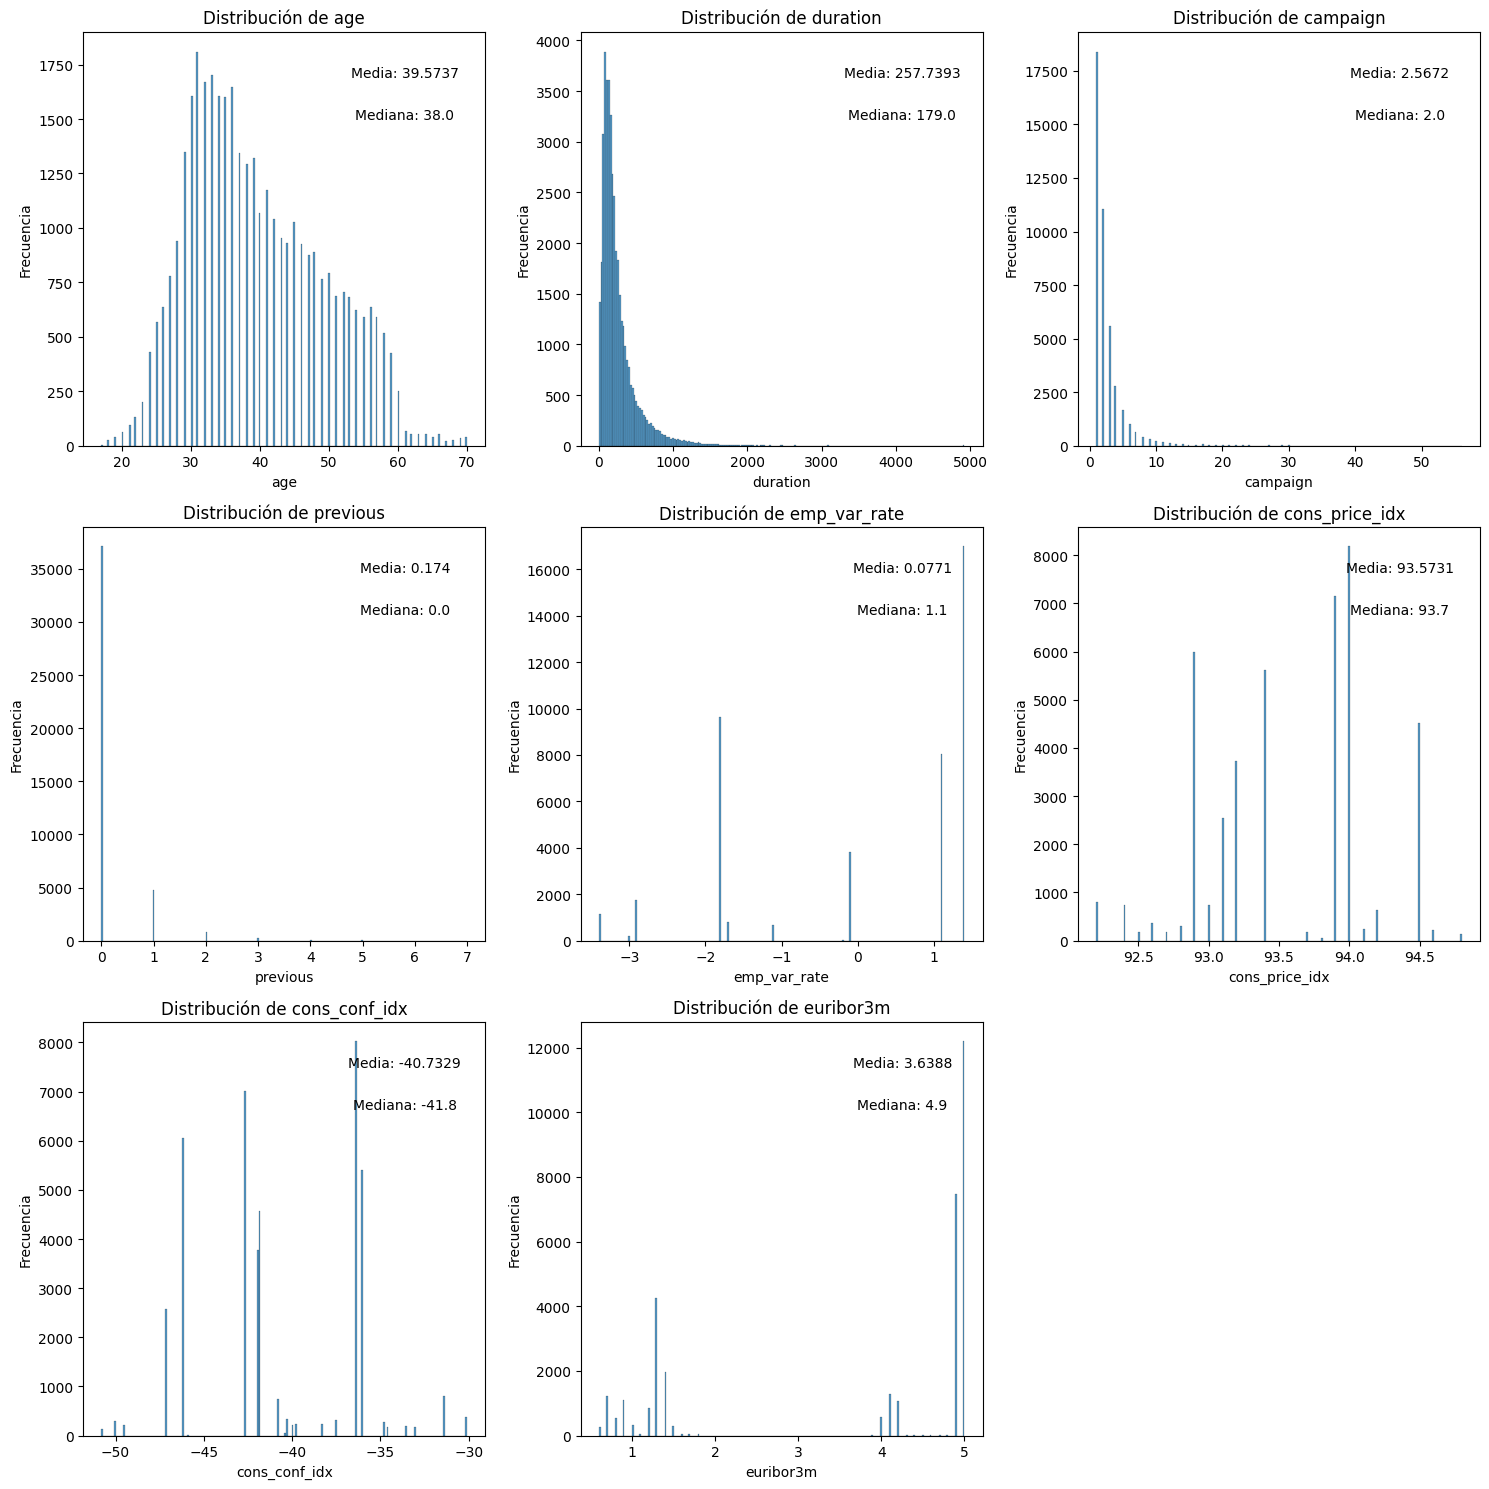

In [6]:
num_graph = len(columnas_num)

num_rows = (num_graph +2 )//3

fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows*5))
axes = axes.flatten()

for i, col in enumerate(columnas_num):
    sns.histplot(data=df, x=col, ax = axes[i], bins=200)
    axes[i].text(0.8, 0.9, f'Media: {round(df[col].mean(),4)}', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
    axes[i].text(0.8, 0.8, f'Mediana: {df[col].median()}', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

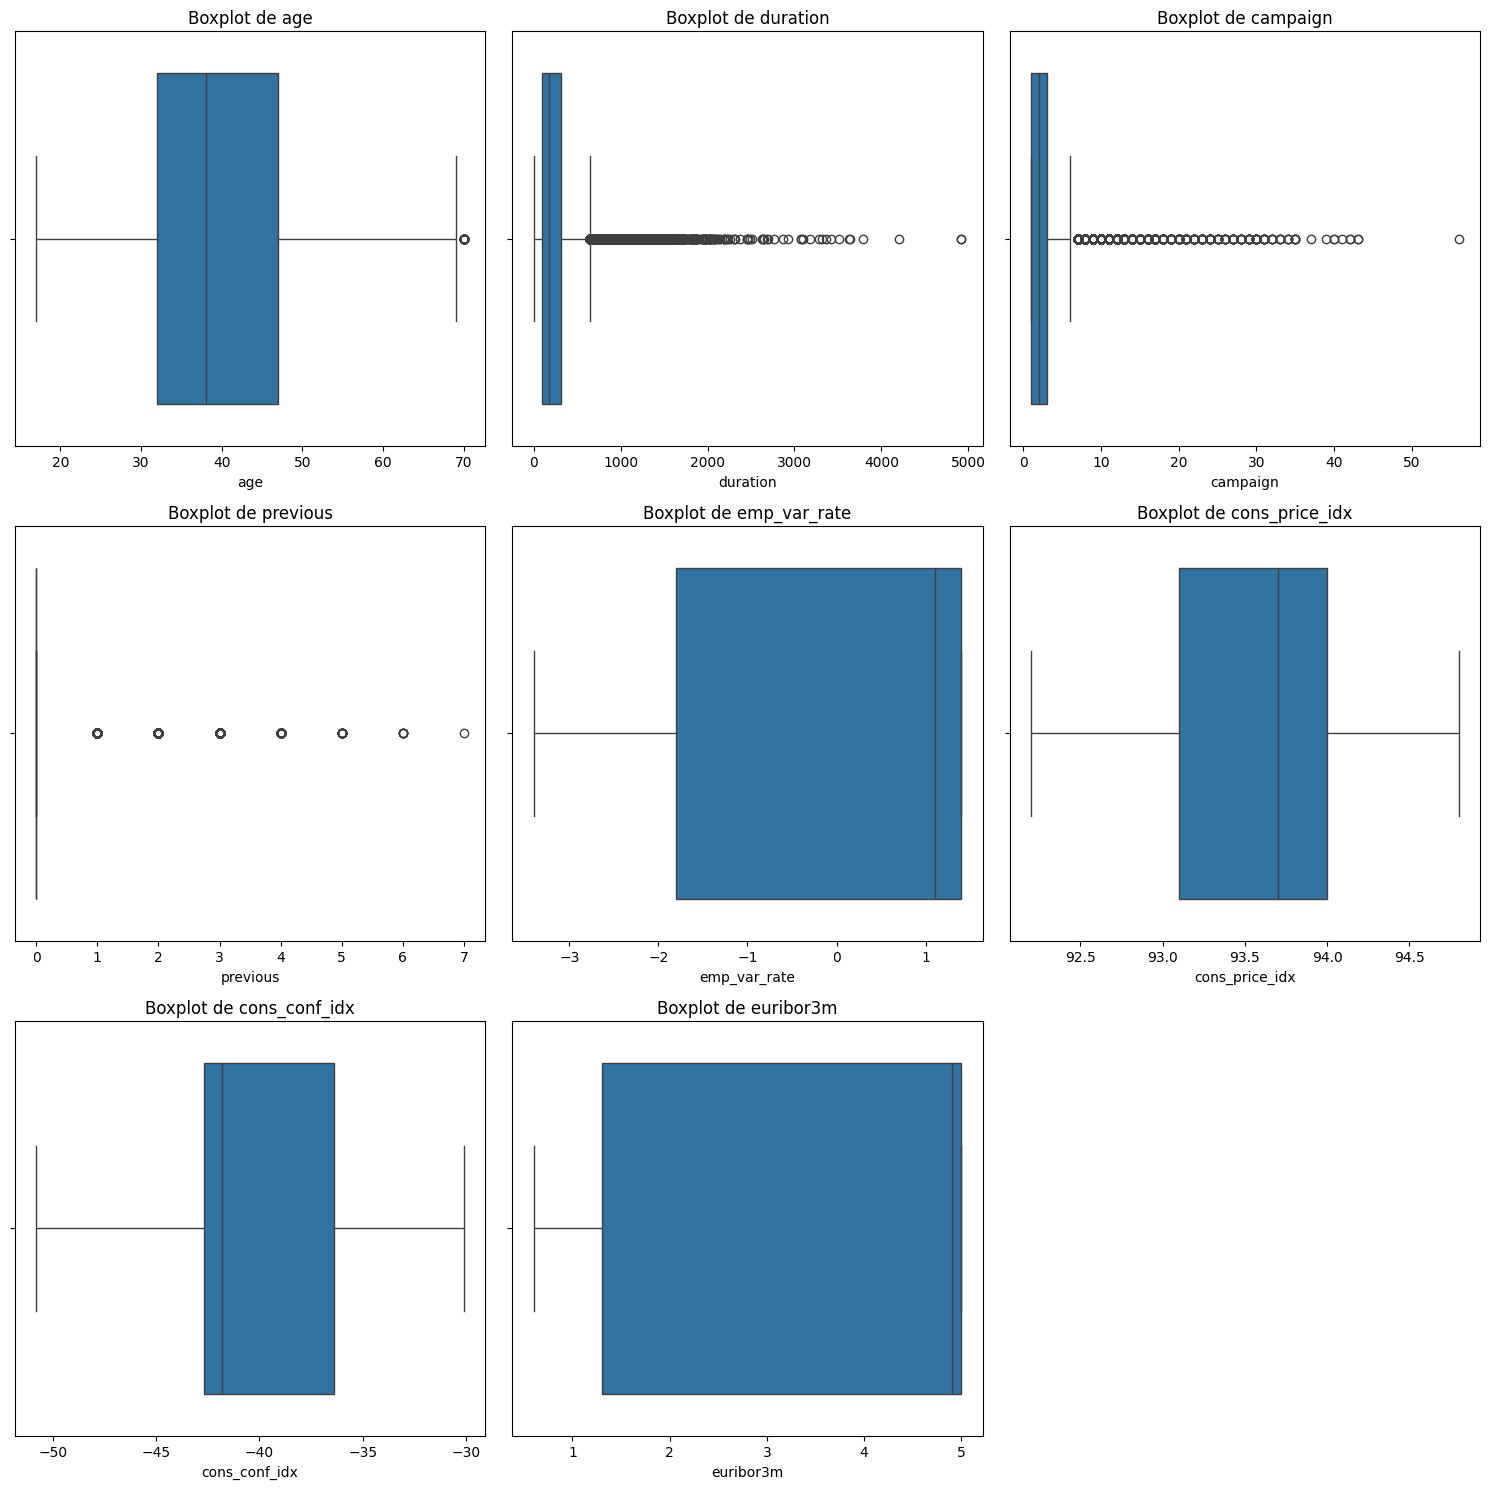

In [7]:
num_graph = len(columnas_num)

num_rows = (num_graph +2 )//3

fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows*5))
axes = axes.flatten()

for i, col in enumerate(columnas_num):
    sns.boxplot(data=df, x=col, ax = axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

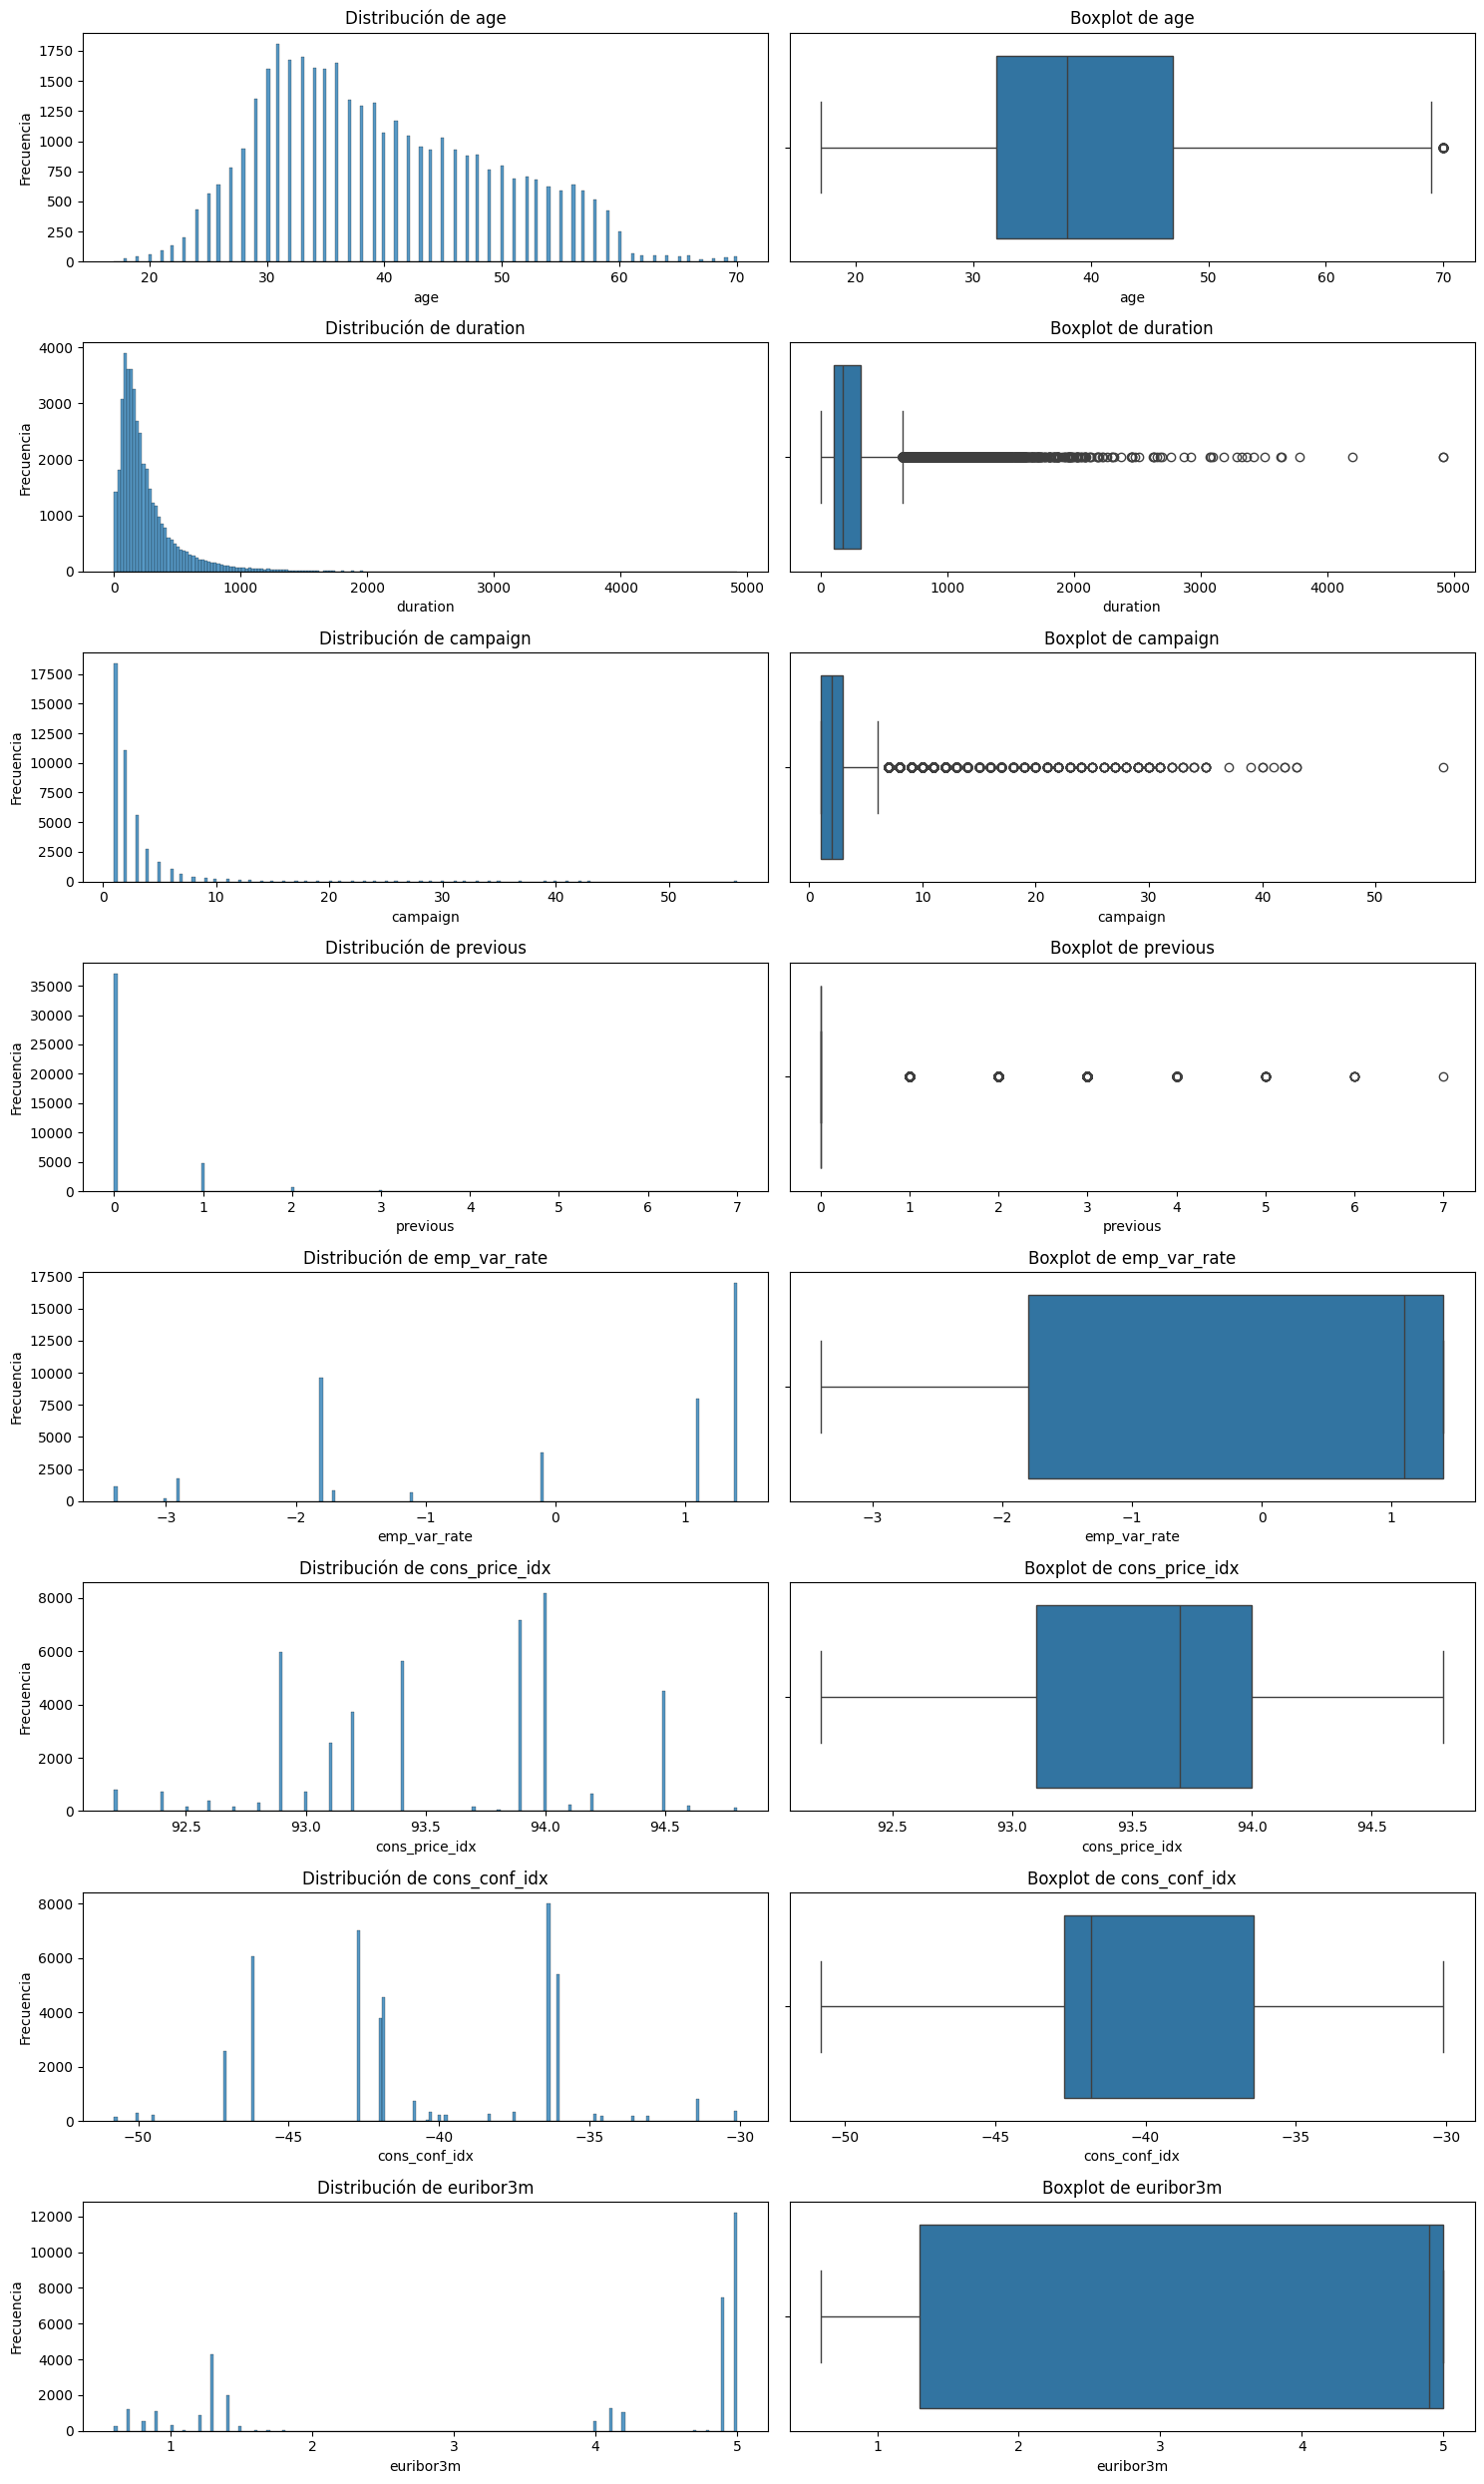

In [8]:
sv.subplot_col_num(df, columnas_num)

In [9]:
dicc_outliers = {'age': 70,
                 'duration': 1000,
                 'campaign' : 10,
                 'previous' : 1,
                 'cons_conf_idx' : -30}

In [10]:
for col, out in dicc_outliers.items():
    outliers = df[col][df[col]> out].count()
    print(f'Para la columna {col.upper()} tenemos {outliers} outliers, lo que representa un {round(outliers/df.shape[0]*100,3)}% de los datos')

Para la columna AGE tenemos 0 outliers, lo que representa un 0.0% de los datos
Para la columna DURATION tenemos 987 outliers, lo que representa un 2.295% de los datos
Para la columna CAMPAIGN tenemos 903 outliers, lo que representa un 2.1% de los datos
Para la columna PREVIOUS tenemos 1119 outliers, lo que representa un 2.602% de los datos
Para la columna CONS_CONF_IDX tenemos 0 outliers, lo que representa un 0.0% de los datos


In [11]:
df['age'] = df['age'].apply(lambda x : np.nan if x > 70 else x)
df['cons_conf_idx'] = df['cons_conf_idx'].apply(lambda x : np.nan if x > -30 else x)

### Gestion de nulos de las columnas numericas

In [12]:
total_nulos, porcentaje_total_nulos = se.calcular_porcentaje_nulos(df)

In [13]:
total_nulos

age               5521
job_grouped        345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx     471
cons_conf_idx      754
euribor3m         9256
nr_employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
year                 0
dtype: int64

In [14]:
porcentaje_total_nulos

age              12.8400
job_grouped       0.8000
marital           0.2000
education         4.2000
default          20.8900
housing           2.3900
loan              2.3900
contact           0.0000
duration          0.0000
campaign          0.0000
pdays             0.0000
previous          0.0000
poutcome          0.0000
emp_var_rate      0.0000
cons_price_idx    1.1000
cons_conf_idx     1.7500
euribor3m        21.5300
nr_employed       0.0000
y                 0.0000
date              0.5800
latitude          0.0000
longitude         0.0000
id_               0.0000
year              0.0000
dtype: float64

In [15]:
col_high_umbral, col_low_umbral = snn.calcular_solo_col_nuls(df)

,Column,Datatype,NullCount,Null%
0,age,float64,5521,12.8395
1,job_grouped,object,345,0.8023
2,marital,object,85,0.1977
3,education,object,1807,4.2023
4,default,float64,8981,20.8860
5,housing,float64,1026,2.3860
6,loan,float64,1026,2.3860
7,cons_price_idx,float64,471,1.0953
8,cons_conf_idx,float64,754,1.7535
9,euribor3m,float64,9256,21.5256


In [17]:
df.to_csv('../Data/data_limpios_bank.csv', index = False)